#  Antiferromagnetic chain with rotating-frame calculation


 Import pyspinw


In [2]:
from pyspinw import *

 Create a 3x8x8 unit cell


In [3]:
unit_cell = UnitCell(3, 8, 8)

 The following generates a 2x1x1 supercell in which the spins alternate in y (period 2 rotation around z)


In [4]:
structure = generate_helical_structure(unit_cell, positions=[[0,0,0]], spins=[[0, 1, 0]],                                   perpendicular=[0,0,1], propagation_vector=[0.5, 0, 0], names=["MCu1"])

 Generate Heisenberg exchanges based on distance, this will only be in x because of the shape of the unit cell


In [5]:
exchanges = generate_exchanges(sites=structure,                               max_distance=3.1,                               exchange_type=HeisenbergExchange,                               j=1)

 Build the Hamiltonian


In [6]:
hamiltonian = Hamiltonian(structure, exchanges)

 You can get a summary of the Hamiltonian using `print_summary` (also works on `Structure`)


In [7]:
hamiltonian.print_summary()

Unit Cell: (3, 8, 8), alpha=90, beta=90, gamma=90
Spacegroup: P1
Supercell: Rotation
  size = (1, 1, 1)
  PropagationVector(0.5, 0, 0)
  Perpendicular=[0, 0, 1]
Sites:
  Site(MCu1, 0, 0, 0, spin=[0. 1. 0.])
Exchanges:
  HeisenbergExchange('J1:MCu1-MCu1', MCu1 <-> MCu1, offset=(1, 0, 0), j=1)


 View it using view


In [8]:
view(hamiltonian)

 Now we can plot a spaghetti diagram, first we generate a path though the lattice
 from $q=0$ to $1$ reciprocal lattice unit in $x$.


In [9]:
path = Path([[0,0,0], [1,0,0]])

 Show a plot


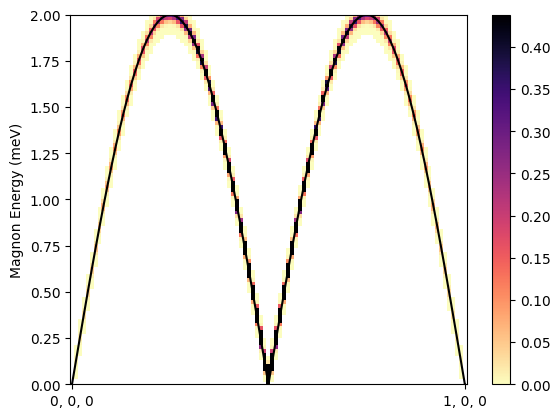

In [10]:
hamiltonian.spaghetti_plot(path, scale='log')